In [5]:
import pandas as pd

df = pd.read_csv("E-commerce data.csv", encoding = 'latin1')   #we have to give datasheet name not folder or file name
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(5268)

In [11]:
df = df.dropna(subset=['CustomerID'])   #remove missing customerID because without customerID cant do customer analysis

In [13]:
df = df.dropna(subset = ['Description'])  #removing missing description

In [14]:
df = df.drop_duplicates()  #dropping duplicates

In [16]:
df = df[df['Quantity'] > 0]    #removing negative sales
df = df[df['UnitPrice'] > 0]  #removing negative / zero price

In [17]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])    #convert date

In [19]:
#creating some imp columns for analysis

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']   #total price
df['Year'] = df['InvoiceDate'].dt.year                #year
df['Month'] = df['InvoiceDate'].dt.month              #month

In [20]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
 9   Year         392692 non-null  int32         
 10  Month        392692 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(4)
memory usage: 33.0+ MB


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
Year           0
Month          0
dtype: int64

In [21]:
#analysis part

df['TotalPrice'].sum()

np.float64(8887208.894000001)

In [23]:
#Revenue Over Time (Monthly Trend)

df.groupby('Month')['TotalPrice'].sum()

Month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087613.170
Name: TotalPrice, dtype: float64

In [24]:
#year-wise revenue

df.groupby('Year')['TotalPrice'].sum()

Year
2010     570422.730
2011    8316786.164
Name: TotalPrice, dtype: float64

In [25]:
#Top 10 produts revenue

df.groupby('Description')['TotalPrice'].sum().sort_values(ascending = False).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalPrice, dtype: float64

In [26]:
#Top countries

df.groupby('Country')['TotalPrice'].sum().sort_values(ascending = False).head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

In [27]:
#Customer analysis 
#high paid 

df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending = False).head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalPrice, dtype: float64

In [28]:
#Customer purchase frequency

df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending = False).head(10)

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

In [30]:
#One-Time Customers

(df.groupby('CustomerID')['InvoiceNo'].nunique() == 1).sum() 

np.int64(1493)

In [31]:
#Most Sold Products (Quantity)

df.groupby('Description')['Quantity'].sum().sort_values(ascending = False).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

In [32]:
#Least performing products

df.groupby('Description')['TotalPrice'].sum().sort_values().head(10)

Description
PADS TO MATCH ALL CUSHIONS             0.003
HEN HOUSE W CHICK IN NEST              0.420
SET 12 COLOURING PENCILS DOILEY        0.650
VINTAGE BLUE TINSEL REEL               0.840
PURPLE FRANGIPANI HAIRCLIP             0.850
PINK CRYSTAL GUITAR PHONE CHARM        0.850
HAPPY BIRTHDAY CARD TEDDY/CAKE         0.950
CAT WITH SUNGLASSES BLANK CARD         0.950
60 GOLD AND SILVER FAIRY CAKE CASES    1.100
BLACKCHRISTMAS TREE 30CM               1.250
Name: TotalPrice, dtype: float64

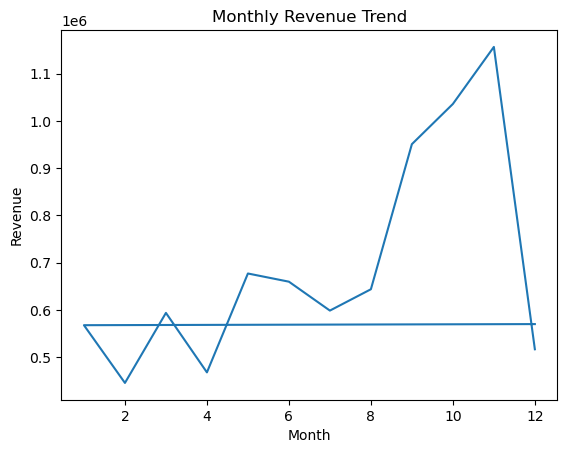

In [33]:
# Revenue trend (Month)

import matplotlib.pyplot as plt

monthly_sales = df.groupby(['Year','Month'])['TotalPrice'].sum().reset_index()

plt.figure()
plt.plot(monthly_sales['Month'], monthly_sales['TotalPrice'])
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

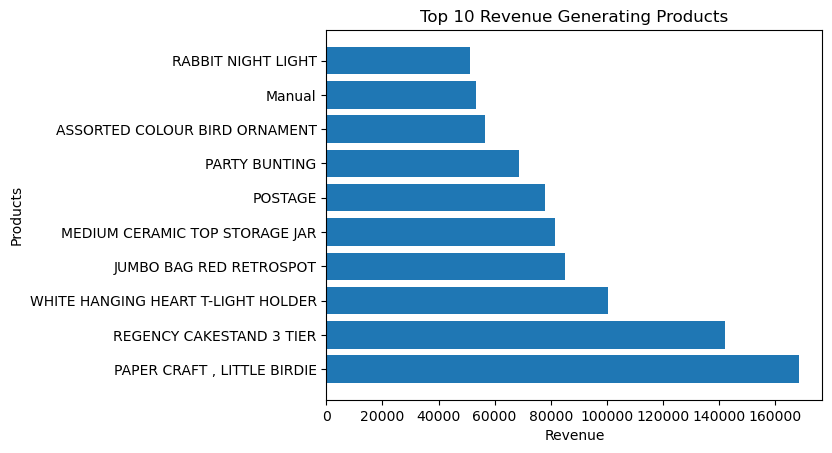

In [34]:
# Top 10 products revenue

top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure()
plt.barh(top_products.index, top_products.values)
plt.title("Top 10 Revenue Generating Products")
plt.xlabel("Revenue")
plt.ylabel("Products")
plt.show()

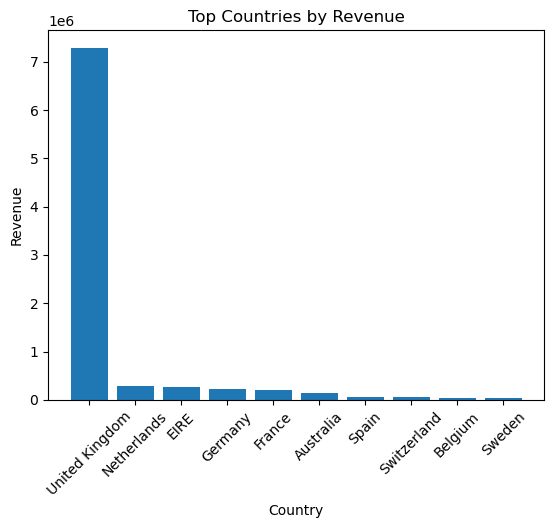

In [35]:
#Top Countries

top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure()
plt.bar(top_countries.index, top_countries.values)
plt.title("Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

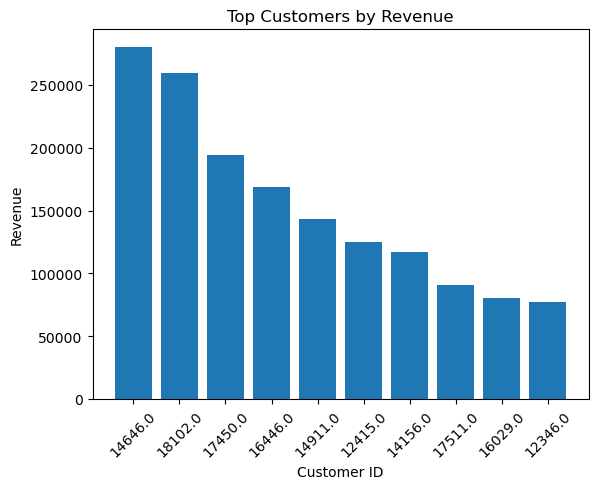

In [36]:
#Top Customers

top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure()
plt.bar(top_customers.index.astype(str), top_customers.values)
plt.title("Top Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

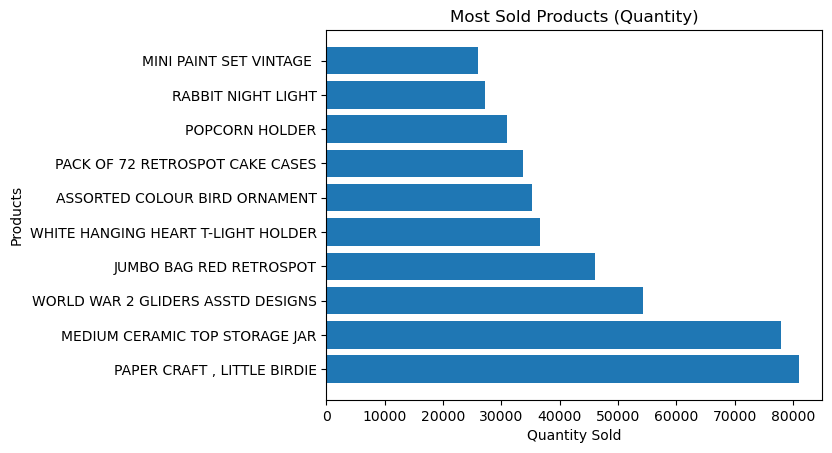

In [37]:
#Most Sold Products

top_quantity = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure()
plt.barh(top_quantity.index, top_quantity.values)
plt.title("Most Sold Products (Quantity)")
plt.xlabel("Quantity Sold")
plt.ylabel("Products")
plt.show()

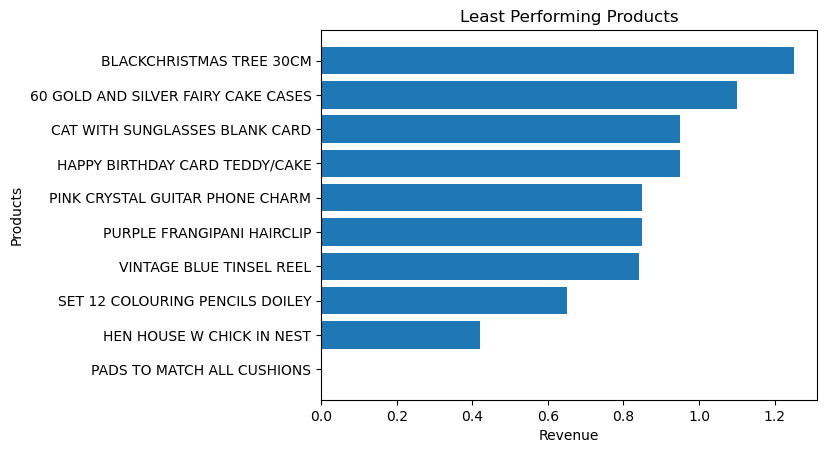

In [38]:
#Least Performing Products

low_products = df.groupby('Description')['TotalPrice'].sum().sort_values().head(10)

plt.figure()
plt.barh(low_products.index, low_products.values)
plt.title("Least Performing Products")
plt.xlabel("Revenue")
plt.ylabel("Products")
plt.show()

In [39]:
df.to_csv("cleaned_ecommerce_data.csv", index=False)